In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

Path to dataset files: C:\Users\anahi\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
488,489,0,3,"Somerton, Mr. Francis William",male,30.0,0,0,A.5. 18509,8.0500,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
581,582,1,1,"Thayer, Mrs. John Borland (Marian Longstreth M...",female,39.0,1,1,17421,110.8833,C68,C
692,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
379,380,0,3,"Gustafsson, Mr. Karl Gideon",male,19.0,0,0,347069,7.7750,NaN,S


In [22]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 12


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [24]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
df.describe(include='str')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [27]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


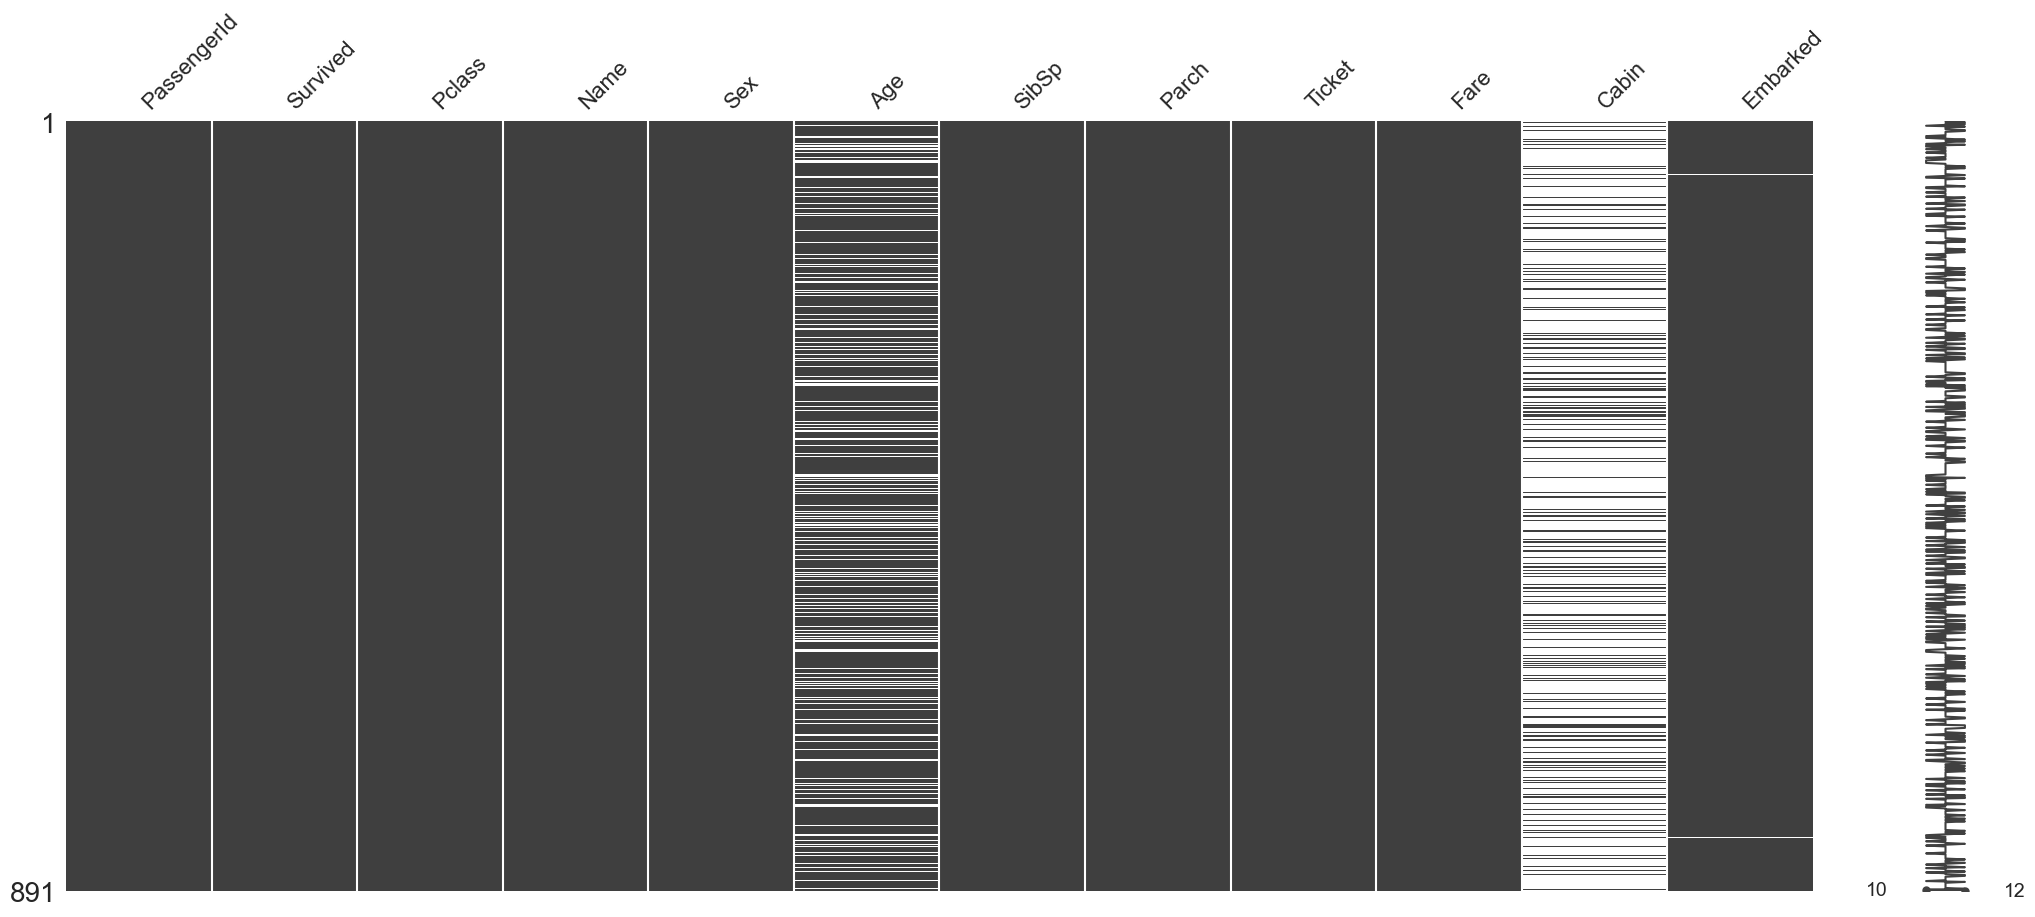

In [28]:
import missingno as msngno
msngno.matrix(df)
plt.show()

In [29]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
print("Dataset después de eliminar columnas:")
df.head()

Dataset después de eliminar columnas:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


Assign 0 to the NaN values in cabin, and 1 to the available ones. Since the people without a cabin number where in 3rd class that probablly means that they didn't have one

In [30]:
df['Cabin'] = df['Cabin'].notnull().astype(int)

Copy-on-Write fixes this by making the rule consistent and explicit: any time you access a subset of a DataFrame, you always get a copy. No exceptions. This means inplace=True on a subset never works, but at least now pandas warns you instead of silently doing nothing.
The tradeoff is that you have to write df['Age'] = df['Age'].fillna(...) explicitly, which is actually clearer — you're explicitly saying "take this column, transform it, put it back into the DataFrame." No ambiguity about whether it worked or not.

In [33]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Valores de Age imputados con la mediana: {median_age}")
df.head(10)

Valores de Age imputados con la mediana: 28.0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,0,S
1,1,1,female,38.0,1,0,71.2833,1,C
2,1,3,female,26.0,0,0,7.9250,0,S
3,1,1,female,35.0,1,0,53.1000,1,S
4,0,3,male,35.0,0,0,8.0500,0,S
5,0,3,male,28.0,0,0,8.4583,0,Q
6,0,1,male,54.0,0,0,51.8625,1,S
7,0,3,male,2.0,3,1,21.0750,0,S
8,1,3,female,27.0,0,2,11.1333,0,S
9,1,2,female,14.0,1,0,30.0708,0,C


In [34]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

print(f"Valores de Embarked imputados con la moda: {mode_embarked}")
df.head(10)

Valores de Embarked imputados con la moda: S


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,0,S
1,1,1,female,38.0,1,0,71.2833,1,C
2,1,3,female,26.0,0,0,7.9250,0,S
3,1,1,female,35.0,1,0,53.1000,1,S
4,0,3,male,35.0,0,0,8.0500,0,S
5,0,3,male,28.0,0,0,8.4583,0,Q
6,0,1,male,54.0,0,0,51.8625,1,S
7,0,3,male,2.0,3,1,21.0750,0,S
8,1,3,female,27.0,0,2,11.1333,0,S
9,1,2,female,14.0,1,0,30.0708,0,C


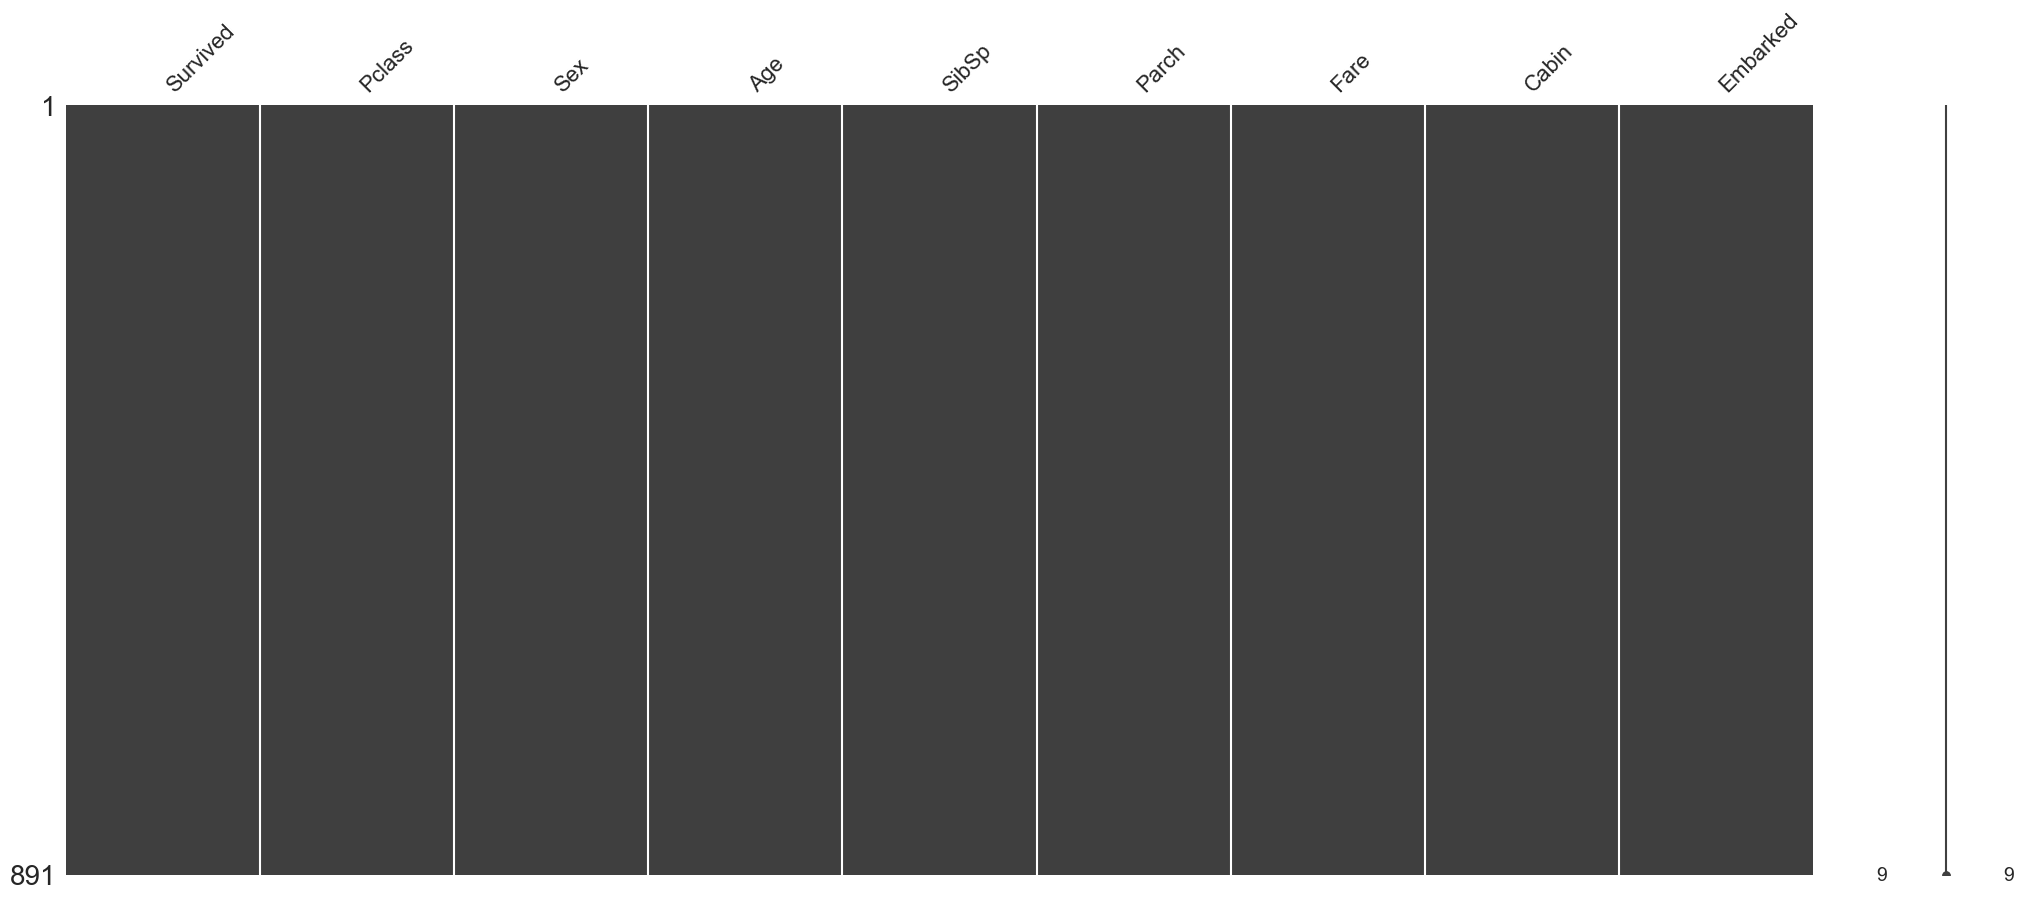

In [35]:
msngno.matrix(df)
plt.show()

In [36]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64


In [37]:
df = df.rename(columns={
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
})

print("Columnas después de renombrar:")
print(df.columns.tolist())
df.head()

Columnas después de renombrar:
['Survived', 'Passenger_Class', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Fare', 'Cabin', 'Embarked']


,Survived,Passenger_Class,Sex,Age,Siblings_Spouses,Parents_Children,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,0,S
1,1,1,female,38.0,1,0,71.2833,1,C
2,1,3,female,26.0,0,0,7.9250,0,S
3,1,1,female,35.0,1,0,53.1000,1,S
4,0,3,male,35.0,0,0,8.0500,0,S


Visualizar con gráfico de barras
kind='bar' crea un gráfico de barras vertical

Survived
0    549
1    342
Name: count, dtype: int64


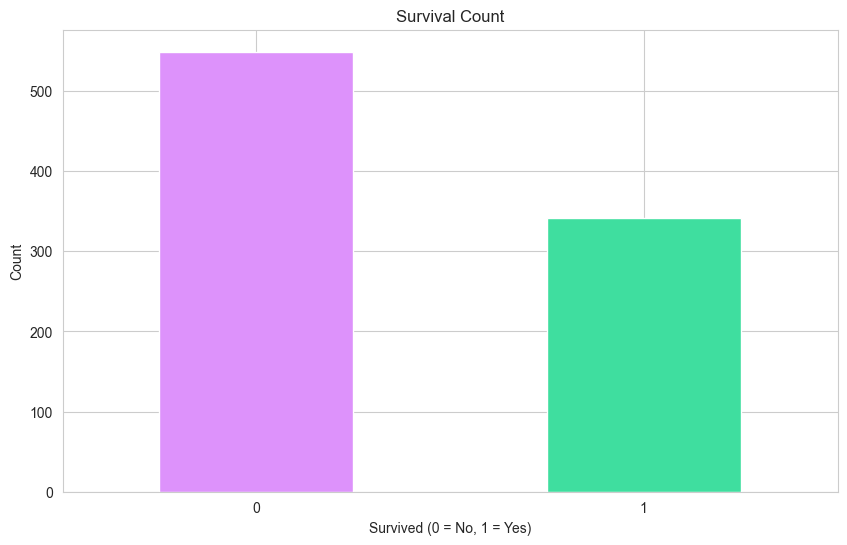

In [42]:
print(df['Survived'].value_counts())

df['Survived'].value_counts().plot(kind='bar', color=['#DD92FB', '#3FDE9F'])
plt.title('Survival Count')  
plt.xlabel('Survived (0 = No, 1 = Yes)')  
plt.ylabel('Count')  
plt.xticks(rotation=0)  
plt.show()

Sex
male      577
female    314
Name: count, dtype: int64


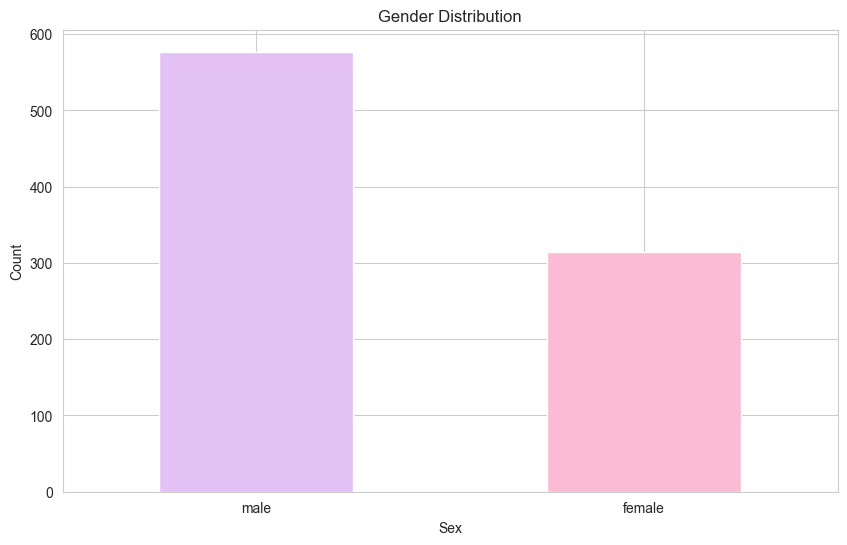

In [44]:
print(df['Sex'].value_counts())


df['Sex'].value_counts().plot(kind='bar', color=['#E4C1F5', '#FABCD4'])
plt.title('Gender Distribution')  
plt.xlabel('Sex')  
plt.ylabel('Count')  
plt.xticks(rotation=0)  
plt.show()

Histograma para ver la distribución de edades
bins=30 dl número de barras/rangos en el gráfico. Más bins = más detalle
edgecolor= añade un borde a cada barra para distinguirlas mejor
alpha=0.7 hace las barras ligeramente transparentes

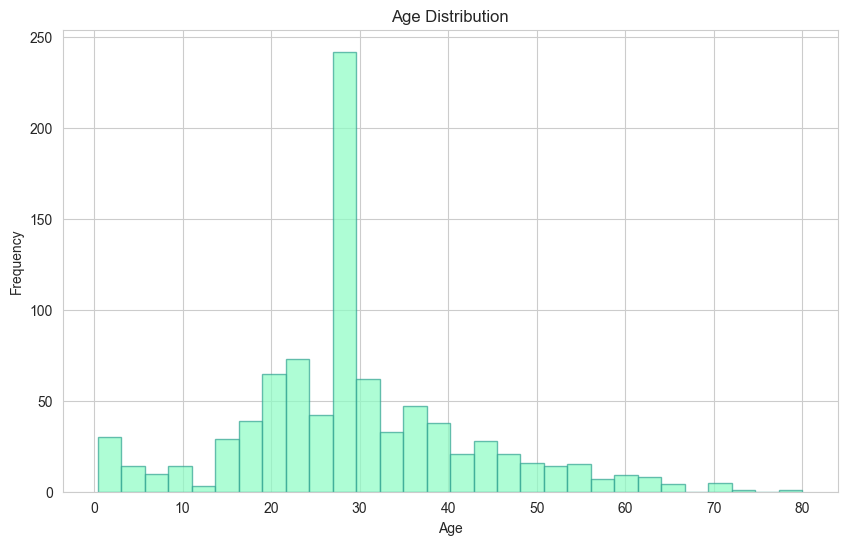

In [45]:
df['Age'].plot(kind='hist', bins=30, edgecolor='#2FA291', alpha=0.7, color='#8CFDC4')
plt.title('Age Distribution')  
plt.xlabel('Age') 
plt.ylabel('Frequency')  
plt.show()

Boxplot para detectar valores extremos (outliers)
Un boxplot muestra la distribución de los datos y resalta valores anómalos. La caja muestra el 50% central de los datos (donde están la mayoría)
La línea en la caja es la mediana (valor del medio)
Los puntos fuera son outliers (valores extremos, como tickets muy caros)

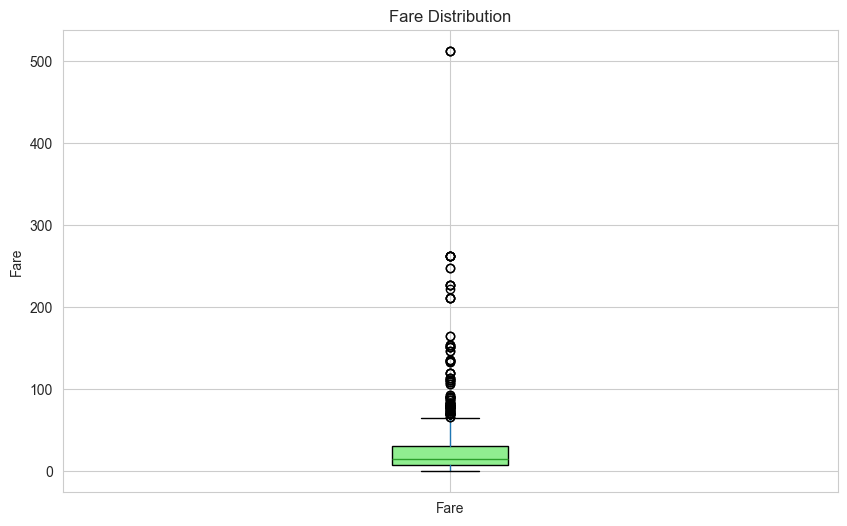

In [46]:
df.boxplot(column='Fare', patch_artist=True, 
           boxprops=dict(facecolor='lightgreen'))
plt.title('Fare Distribution')  
plt.ylabel('Fare')  
plt.show()

 Tabla cruzada para ver la relación entre sexo y supervivencia
normalize='index' calcula porcentajes por fila (por sexo). Por ejemplo: del total de mujeres, ¿qué % sobrevivió?

In [47]:
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print("Porcentaje de supervivencia por sexo:")
print(survival_by_sex)

Porcentaje de supervivencia por sexo:
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


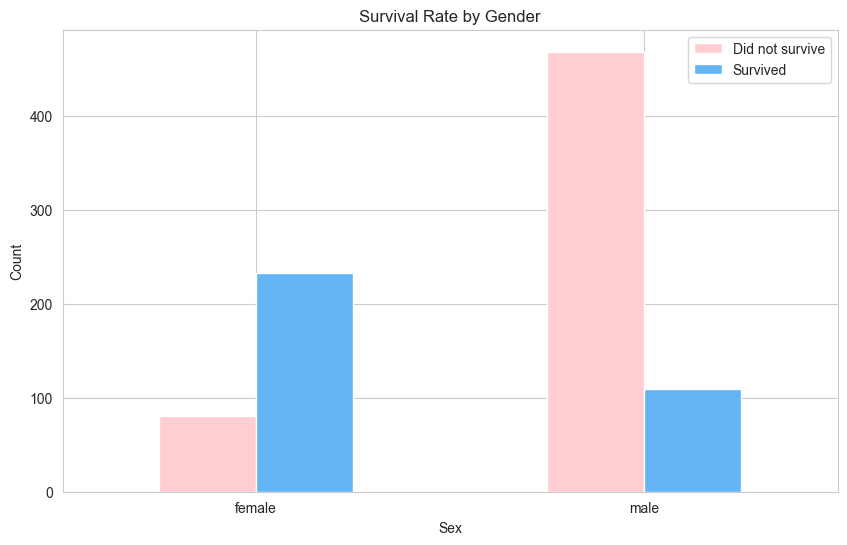

In [48]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', color=['#FFCDD2', '#64B5F6'])
plt.title('Survival Rate by Gender')  
plt.xlabel('Sex')  
plt.ylabel('Count')  
plt.legend(['Did not survive', 'Survived'])  
plt.xticks(rotation=0)  
plt.show()

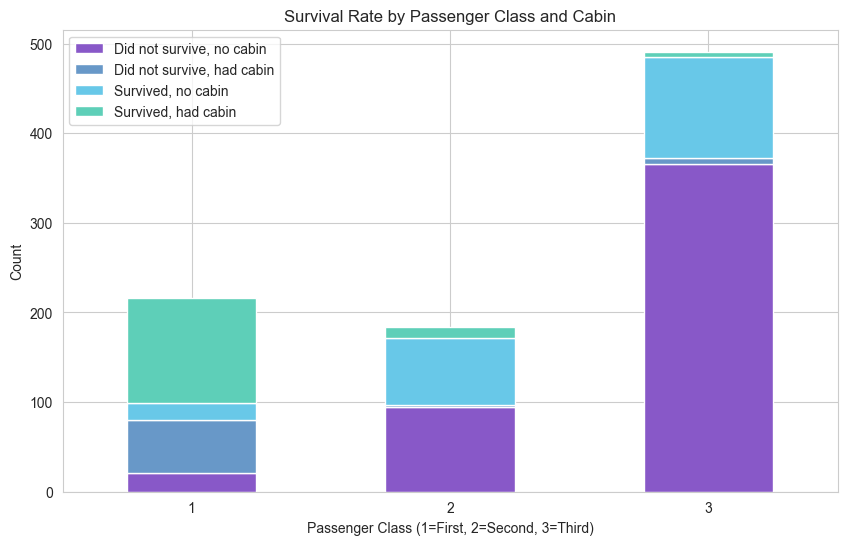

In [54]:
pd.crosstab(df['Passenger_Class'], [df['Survived'], df['Cabin']]).plot(kind='bar', stacked=True,
                                                               color=['#8858C8', '#6898C8', '#68C8E8', '#5ECFB8'])
plt.title('Survival Rate by Passenger Class and Cabin')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(['Did not survive, no cabin', 'Did not survive, had cabin',
            'Survived, no cabin', 'Survived, had cabin'])
plt.xticks(rotation=0)
plt.show()

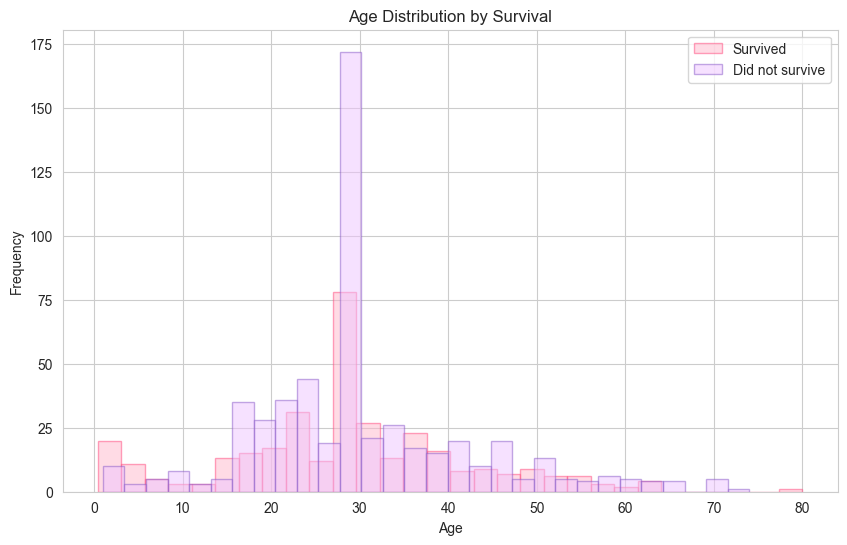

In [55]:
df[df['Survived']==1]['Age'].plot(kind='hist', bins=30, alpha=0.5,
                                   label='Survived', color='#FFB8CC', edgecolor='#FF477B')
df[df['Survived']==0]['Age'].plot(kind='hist', bins=30, alpha=0.5,
                                   label='Did not survive', color='#EFC4FF', edgecolor='#8858C8')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

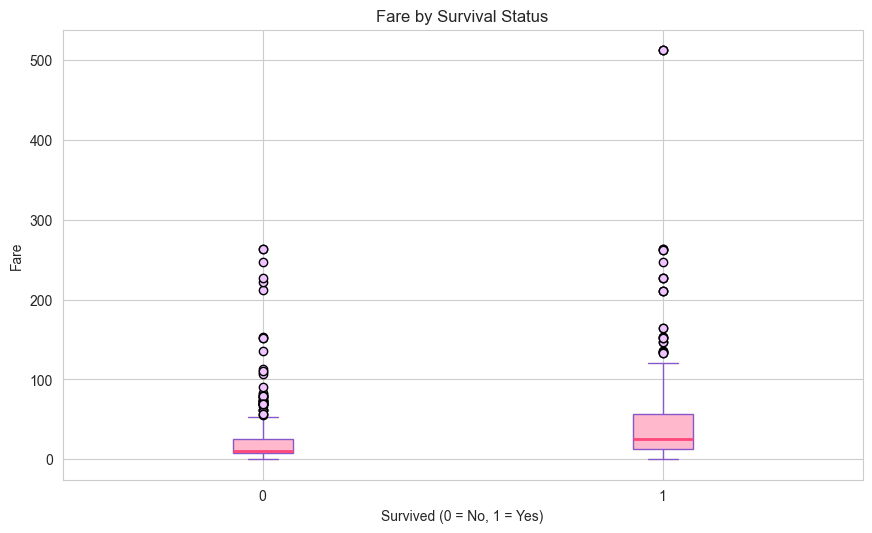

In [56]:
df.boxplot(column='Fare', by='Survived', patch_artist=True,
           boxprops=dict(facecolor='#FFB8CC', color='#8858C8'),
           medianprops=dict(color='#FF477B', linewidth=2),
           whiskerprops=dict(color='#8858C8'),
           capprops=dict(color='#8858C8'),
           flierprops=dict(markerfacecolor='#EFC4FF', marker='o'))
plt.title('Fare by Survival Status')
plt.suptitle('')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

Calcular correlaciones SOLO entre variables numéricas
select_dtypes(include=[np.number]) selecciona solo columnas con números
Esto evita errores con columnas de texto como 'Sex' o 'Embarked'

In [58]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
print("Matriz de correlación entre variables numéricas:")
print(correlation)

Matriz de correlación entre variables numéricas:
                  Survived  Passenger_Class       Age  Siblings_Spouses  \
Survived          1.000000        -0.338481 -0.064910         -0.035322   
Passenger_Class  -0.338481         1.000000 -0.339898          0.083081   
Age              -0.064910        -0.339898  1.000000         -0.233296   
Siblings_Spouses -0.035322         0.083081 -0.233296          1.000000   
Parents_Children  0.081629         0.018443 -0.172482          0.414838   
Fare              0.257307        -0.549500  0.096688          0.159651   
Cabin             0.316912        -0.725541  0.240314         -0.040460   

                  Parents_Children      Fare     Cabin  
Survived                  0.081629  0.257307  0.316912  
Passenger_Class           0.018443 -0.549500 -0.725541  
Age                      -0.172482  0.096688  0.240314  
Siblings_Spouses          0.414838  0.159651 -0.040460  
Parents_Children          1.000000  0.216225  0.036987  
Fare    

Heatmap - Gráfico donde los colores representan valores.
¿Qué es annot=True? Muestra los números dentro de cada celda para saber el valor exacto.

¿Para qué sirve?
Para identificar rápidamente qué variables están más relacionadas con 'Survived'. Por ejemplo, si 'Passenger_Class' tiene correlación negativa con 'Survived', significa que clases más altas (3) sobrevivieron menos.

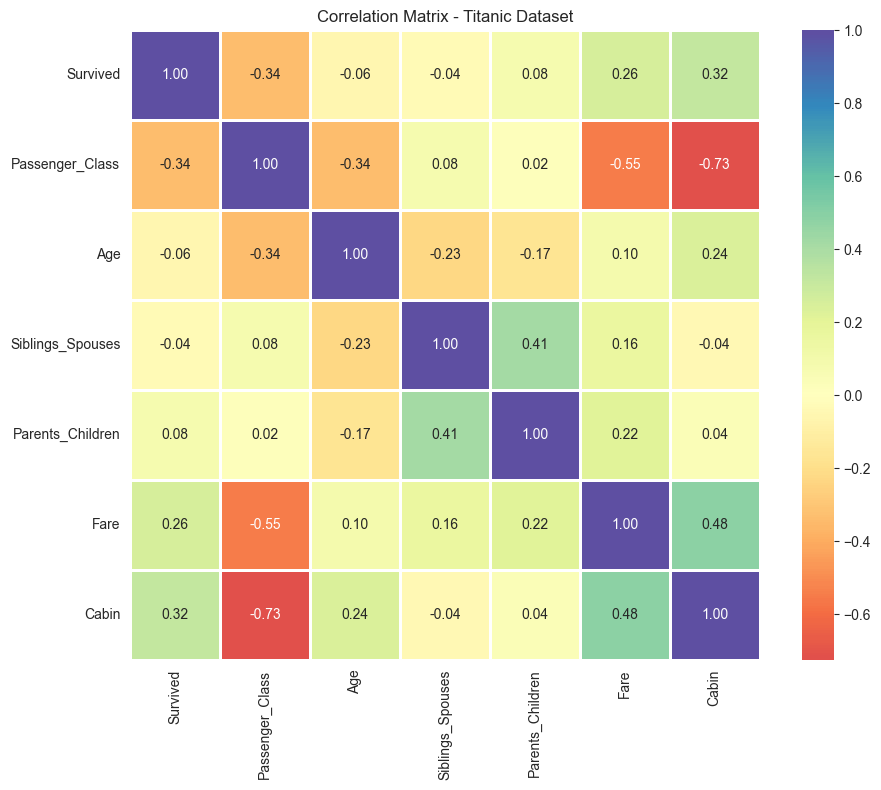

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='Spectral', center=0,
            linewidths=1, fmt='.2f', square=True)
plt.title('Correlation Matrix - Titanic Dataset')
plt.tight_layout()
plt.show()

¿Qué es un pairplot?
Crea una matriz de gráficos mostrando todas las combinaciones posibles de variables. En la diagonal muestra histogramas de cada variable.

¿Qué es hue='Survived'?
Colorea los puntos según si sobrevivieron o no. Esto nos ayuda a ver patrones de supervivencia.

¿Para qué sirve?
Para identificar visualmente relaciones complejas entre múltiples variables. Por ejemplo, podemos ver si hay un patrón entre edad, precio del ticket y supervivencia simultáneamente.

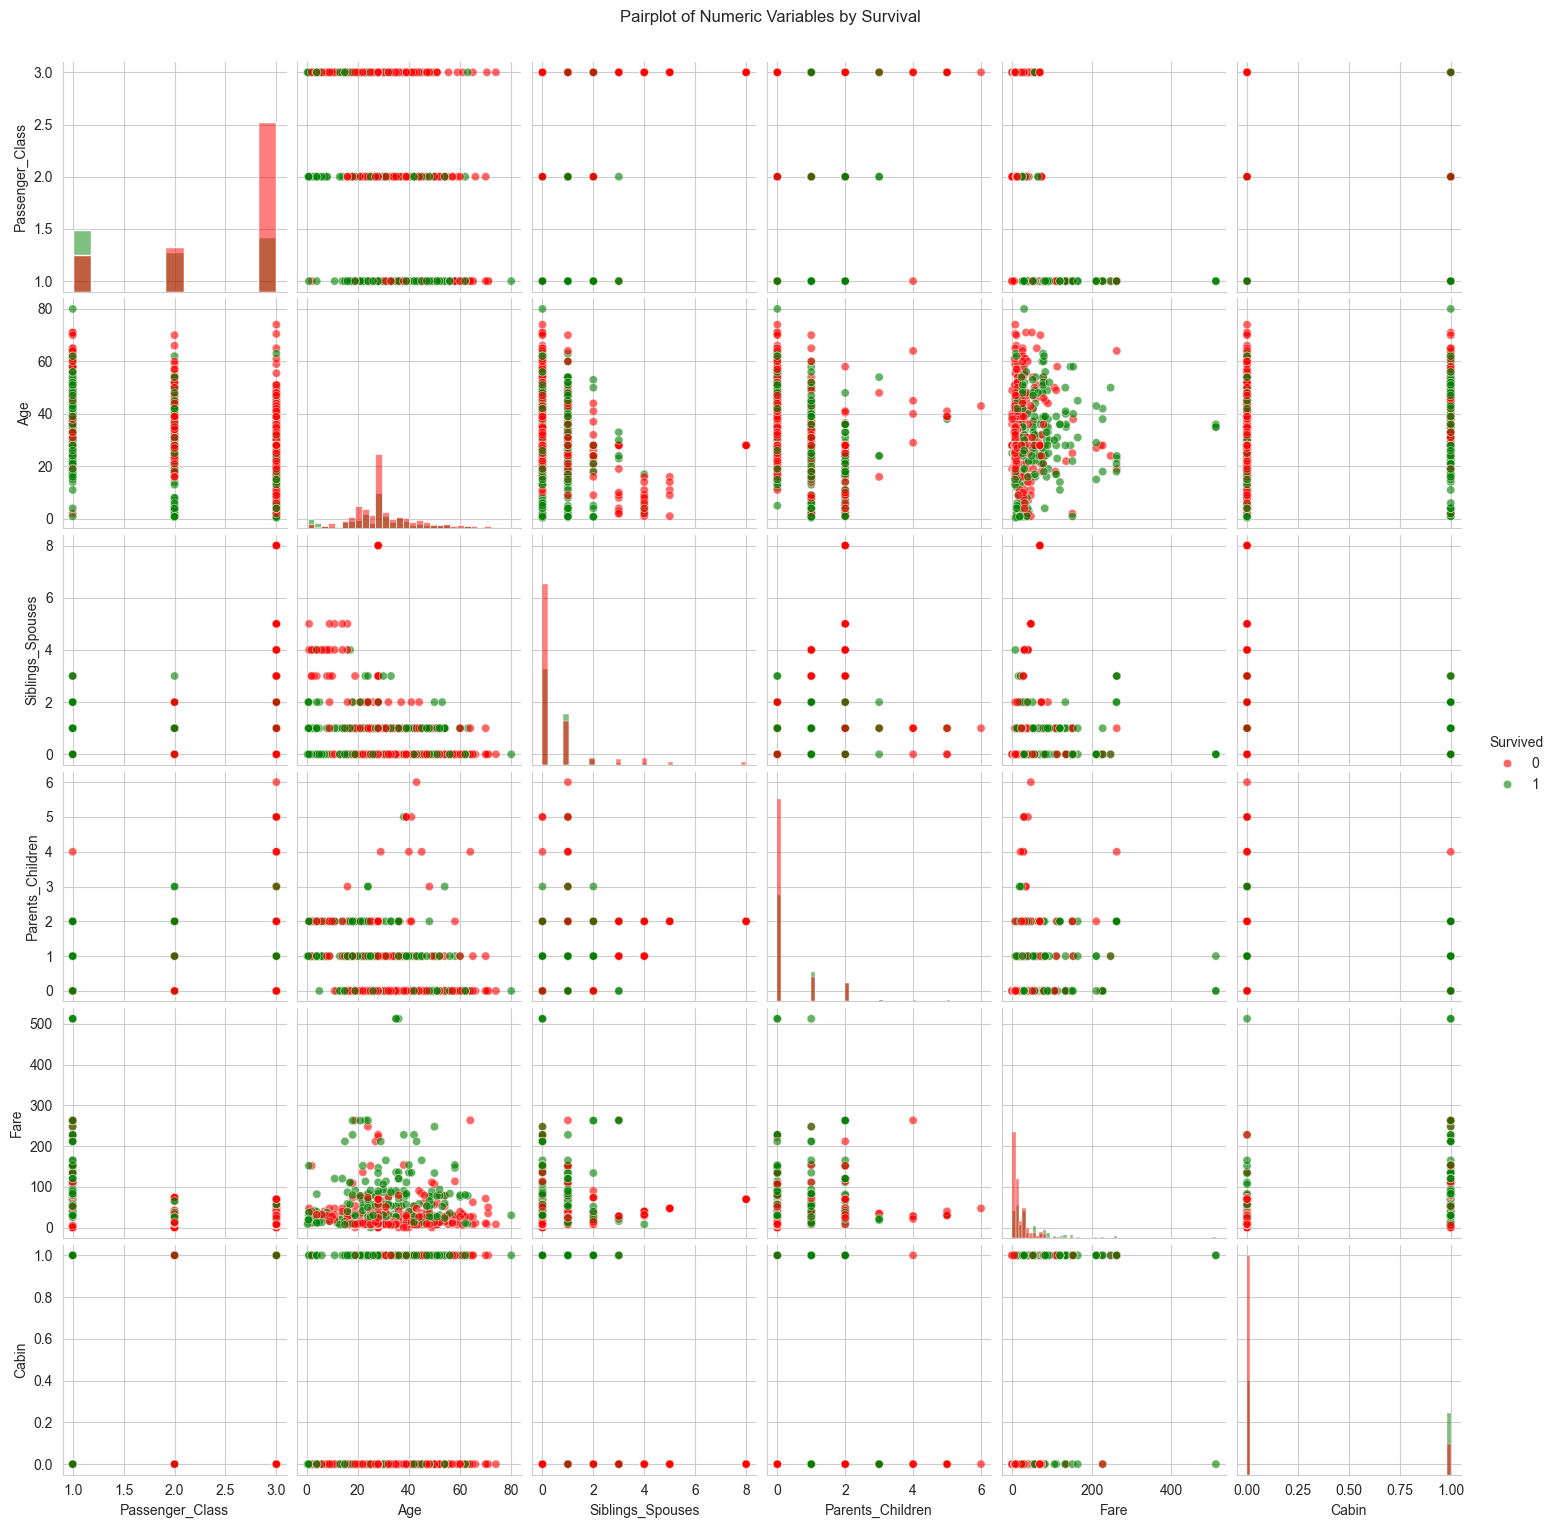

In [61]:

sns.pairplot(numeric_df, hue='Survived', palette={0: 'red', 1: 'green'}, 
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Numeric Variables by Survival', y=1.02) 
plt.show()

In [62]:
df['Family_Size'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1

print("Nueva columna Family_Size creada:")
df[['Siblings_Spouses', 'Parents_Children', 'Family_Size']].head(10)

Nueva columna Family_Size creada:


,Siblings_Spouses,Parents_Children,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


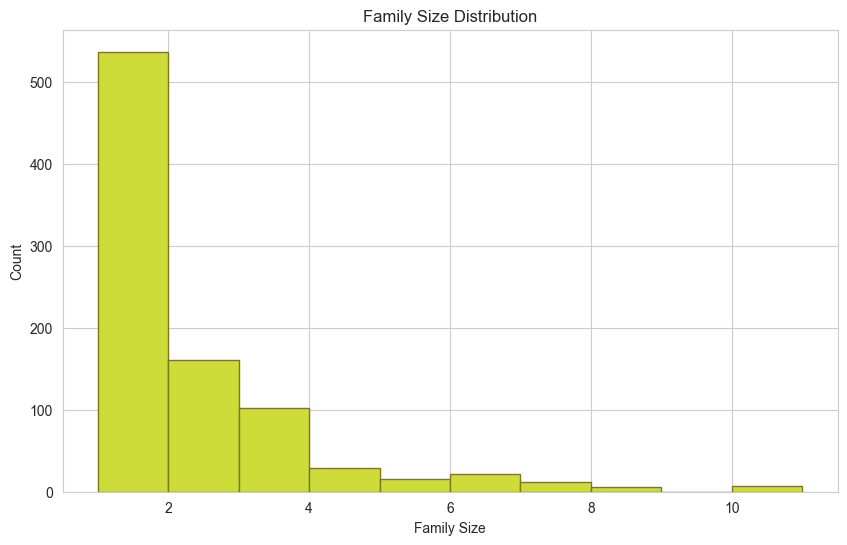

In [63]:
df['Family_Size'].plot(kind='hist', bins=10, edgecolor='#827717', color='#CDDC39')
plt.title('Family Size Distribution')  
plt.xlabel('Family Size')  
plt.ylabel('Count')  
plt.show()

In [64]:
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

print("Nueva columna Is_Alone creada:")
df[['Family_Size', 'Is_Alone']].head(10)

Nueva columna Is_Alone creada:


,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


¿Qué es .astype(int)?
Convierte True/False a 1/0. Es más fácil trabajar con números. ¿Para qué sirve?
Para investigar si estar solo fue una ventaja o desventaja. Quizás los que viajaban solos se movieron más rápido hacia los botes salvavidas.

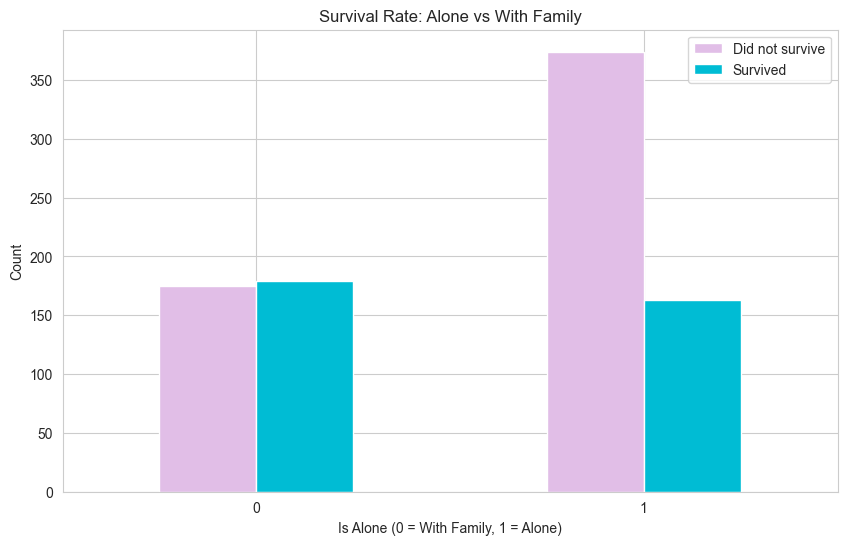

In [65]:
pd.crosstab(df['Is_Alone'], df['Survived']).plot(kind='bar', color=['#E1BEE7', '#00BCD4'])
plt.title('Survival Rate: Alone vs With Family')  
plt.xlabel('Is Alone (0 = With Family, 1 = Alone)')  
plt.ylabel('Count')  
plt.xticks(rotation=0)
plt.legend(['Did not survive', 'Survived'])
plt.show()

Categorizar edades en grupos significativos
bins define los límites de cada grupo
labels define los nombres de cada categoría. ¿Qué es pd.cut()?
Divide una variable continua (edad) en categorías discretas (grupos). Por ejemplo, 5 años → Child, 25 años → Young Adult.

In [66]:
df['Age_Group'] = pd.cut(df['Age'], 
                         bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

# Ver la nueva columna de grupos de edad
print("Nueva columna Age_Group creada:")
df[['Age', 'Age_Group']].head(15)

Nueva columna Age_Group creada:


,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


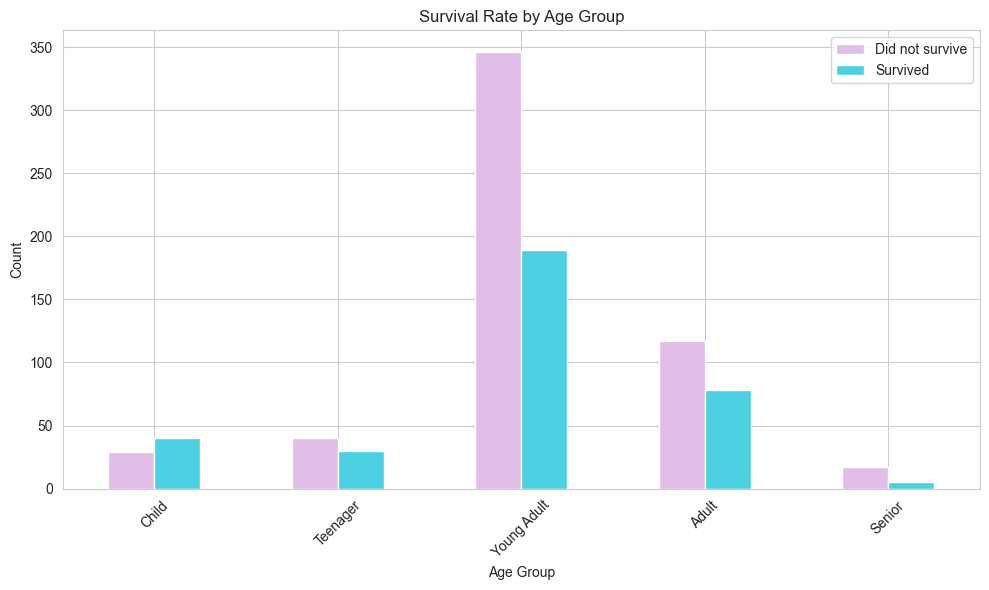

In [68]:
pd.crosstab(df['Age_Group'], df['Survived']).plot(kind='bar', color=['#E1BEE7', '#4DD0E1'])
plt.title('Survival Rate by Age Group')  
plt.xlabel('Age Group') 
plt.ylabel('Count')  
plt.xticks(rotation=45)  
plt.legend(['Did not survive', 'Survived'])
plt.tight_layout()  
plt.show()

In [69]:
# Ejemplo de conclusiones basadas en el análisis

print("=== CONCLUSIONES DEL ANÁLISIS ===\n")

# 1. Tasa de supervivencia general
survival_rate = (df['Survived'].sum() / len(df)) * 100
print(f"1. Tasa de supervivencia general: {survival_rate:.2f}%\n")

# 2. Supervivencia por sexo
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print("2. Tasa de supervivencia por sexo:")
print(survival_by_sex)
print()

# 3. Supervivencia por clase
survival_by_class = df.groupby('Passenger_Class')['Survived'].mean() * 100
print("3. Tasa de supervivencia por clase:")
print(survival_by_class)
print()

# 4. Edad promedio de sobrevivientes vs no sobrevivientes
avg_age = df.groupby('Survived')['Age'].mean()
print("4. Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")

=== CONCLUSIONES DEL ANÁLISIS ===

1. Tasa de supervivencia general: 38.38%

2. Tasa de supervivencia por sexo:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

3. Tasa de supervivencia por clase:
Passenger_Class
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

4. Edad promedio:
   No sobrevivientes: 30.03 años
   Sobrevivientes: 28.29 años
